# TUs simulation safety parameter plots

In [40]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [41]:
# Make output folder
plot_dir = os.path.join('..','plots','simulation_safety_parameters')
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

### Find all csv's from the stimulation output folder

In [42]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/planning/'

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')

stimulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True)
print(stimulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-010/sub-010_layered_output_table_target_1_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-010/sub-010_layered_output_table_target_1_6_dc10_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-003/sub-003_layered_output_table_target_1_6_dc10_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-003/sub-003_layered_output_table_target_1_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-005/sub-005_layered_output_table_target_1_6_dc10_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-005/sub-005_layered_output_table_target_1_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-702/sub-702_layered_output_table_target_1_6_dc10_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/

### Save them in one dataframe
And add columns with the individual subject_id's, targets etc

In [43]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for stimulation_output_full_filename in stimulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(stimulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]
    
    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')
    
    # Extract the desired parts from the filename:
    subject_id = stimulation_output_filename_parts[0]                     # e.g. 'sub-010'
    target = '_'.join(stimulation_output_filename_parts[4:7])               # e.g. 'target_2_2'
    duty_cycle = stimulation_output_filename_parts[7]                       # e.g. 'dc1'
    intensity = '_'.join(stimulation_output_filename_parts[8:10])           # e.g. 'strength_1'
    
    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(stimulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {stimulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the extracted metadata as new columns
    df['target'] = target
    df['intensity'] = intensity
    df['duty_cycle'] = duty_cycle
    
    # Append the dataframe to our list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

     subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0            10   17.02263                   17.022630            48.002604   
1            10   17.02263                   17.022630            48.002604   
2             3   15.27858                   15.278580            64.048810   
3             3   15.27858                   15.278580            64.048810   
4             5   17.93337                   17.933370            57.508695   
..          ...        ...                         ...                  ...   
258           3   10.49453                    7.200387            42.514703   
259           3   10.49453                    7.200387            42.514703   
260           3   15.05523                   15.055230            43.014532   
261           3   19.40464                   19.404640            43.014532   
262           3   32.52235                   22.313920            42.514703   

     max_Isppa_skin  max_Isppa_skull  max_Isppa_bra

### Reorder the dataframe and replace strings

In [44]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target', 'intensity', 'duty_cycle'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)
stimulation_output['CEM43_brain_skin'] = stimulation_output[['CEM43_brain', 'CEM43_skin']].max(axis=1)
# Replace values to improve readability
stimulation_output['duty_cycle'] = stimulation_output['duty_cycle'].map({'dc10': '10%', 'dc15': '15%', 'dc20': '20%'})
stimulation_output['intensity'] = stimulation_output['intensity'].map({'strength_1': '35', 'strength_2': '63', 'strength_3': '81', 'strength_4': '110'})
# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'CEM43_brain', 'CEM43_skull', 'CEM43_skin', 
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

print(stimulation_output)

     subject_id      target intensity duty_cycle  max_Isppa  \
0             3  target_1_1        35        10%   22.93461   
1             3  target_1_1        35        20%   22.93461   
2             3  target_1_2        35        10%   15.27858   
3             3  target_1_2        35        20%   15.27858   
4             3  target_1_3        35        10%   22.93461   
..          ...         ...       ...        ...        ...   
258         702  target_2_5        81        15%   30.70593   
259         702  target_2_5        81        20%   15.37161   
260         702  target_2_6        63        20%   20.14590   
261         702  target_2_6        81        10%   25.96599   
262         702  target_2_6        81        20%   25.96599   

     max_Isppa_after_exit_plane  max_Isppa_skin  max_Isppa_skull  \
0                     22.934610        22.93461         6.330170   
1                     22.934610        22.93461         6.330170   
2                     15.278580        

## Now plot the most important safety parameters

### Mechanical index
Aim for a value below 1.9, plot separately for skin, skull and brain.
Group by target, intensity and duty cycle

#### Skin

     subject_id      target intensity duty_cycle  max_MI_skin
1             3  target_1_1        35        20%     1.638047
3             3  target_1_2        35        20%     1.220471
5             3  target_1_3        35        20%     1.638047
7             3  target_1_4        35        20%     1.220471
9             3  target_1_5        35        20%     1.638047
11            3  target_1_6        35        20%     1.220471
72            4  target_1_1        35        20%     1.179430
80            5  target_1_1        35        20%     1.402398
82            5  target_1_2        35        20%     1.448477
84            5  target_1_3        35        20%     1.402398
86            5  target_1_4        35        20%     1.448477
88            5  target_1_5        35        20%     1.402398
90            5  target_1_6        35        20%     1.448477
142          10  target_1_1        35        20%     1.418002
144          10  target_1_2        35        20%     1.391674
146     

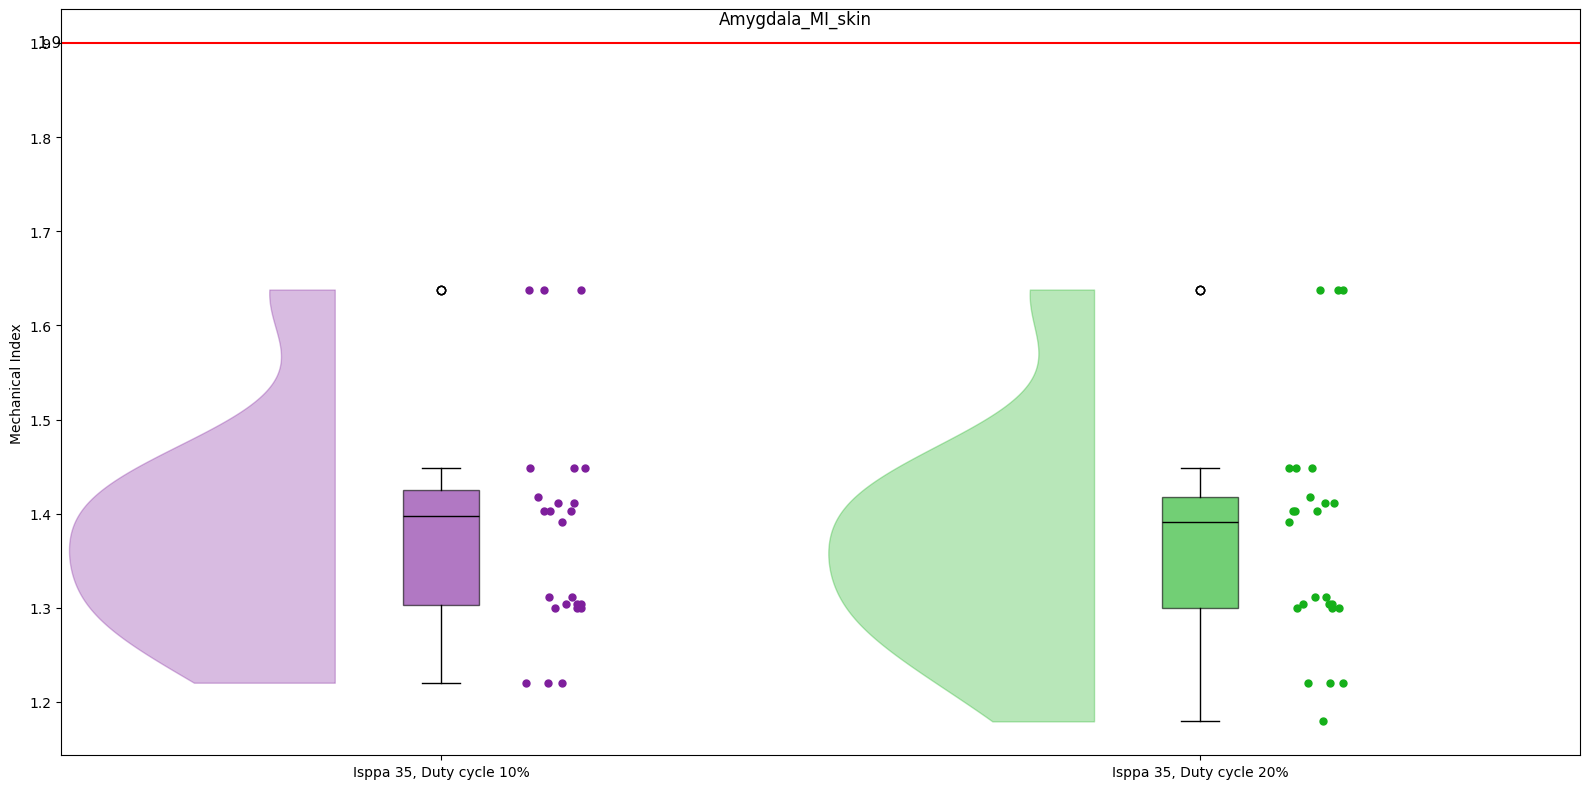

In [45]:
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_1_6') | (stimulation_output['target'] == 'target_1_5') | (stimulation_output['target'] == 'target_1_4') | (stimulation_output['target'] == 'target_1_3') | (stimulation_output['target'] == 'target_1_2') | (stimulation_output['target'] == 'target_1_1')) & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '10%')]
list_1 = dataframe_filtered['max_MI_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_1_6') | (stimulation_output['target'] == 'target_1_5') | (stimulation_output['target'] == 'target_1_4') | (stimulation_output['target'] == 'target_1_3') | (stimulation_output['target'] == 'target_1_2') | (stimulation_output['target'] == 'target_1_1')) & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '20%')]
list_2 = dataframe_filtered['max_MI_skin'].dropna().tolist()
print(dataframe_filtered[['subject_id', 'target', 'intensity', 'duty_cycle', 'max_MI_skin']])
raincloud_plot_list = [list_1, list_2]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))
#ax.set_yscale('log')
plt.axhline(y = 1.9, color = 'r', linestyle = '-')
ax.text(x=0, y=1.9, s='1.9', va='center', ha='right',
        transform=ax.get_yaxis_transform(), fontsize=11)

# Create a list of colors
plot_colors = ['#7E1E9C', '#15B01A']
c = 'black'

# Boxplot data
bp = ax.boxplot(raincloud_plot_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(raincloud_plot_list, points=500, positions=[0.86, 1.86], widths=0.7,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(raincloud_plot_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=25, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Isppa 35, Duty cycle 10%', 'Isppa 35, Duty cycle 20%'])
plt.ylabel('Mechanical Index')
plot_name = 'Amygdala_MI_skin'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(plot_dir, f'{plot_name}.pdf'))
plt.show()

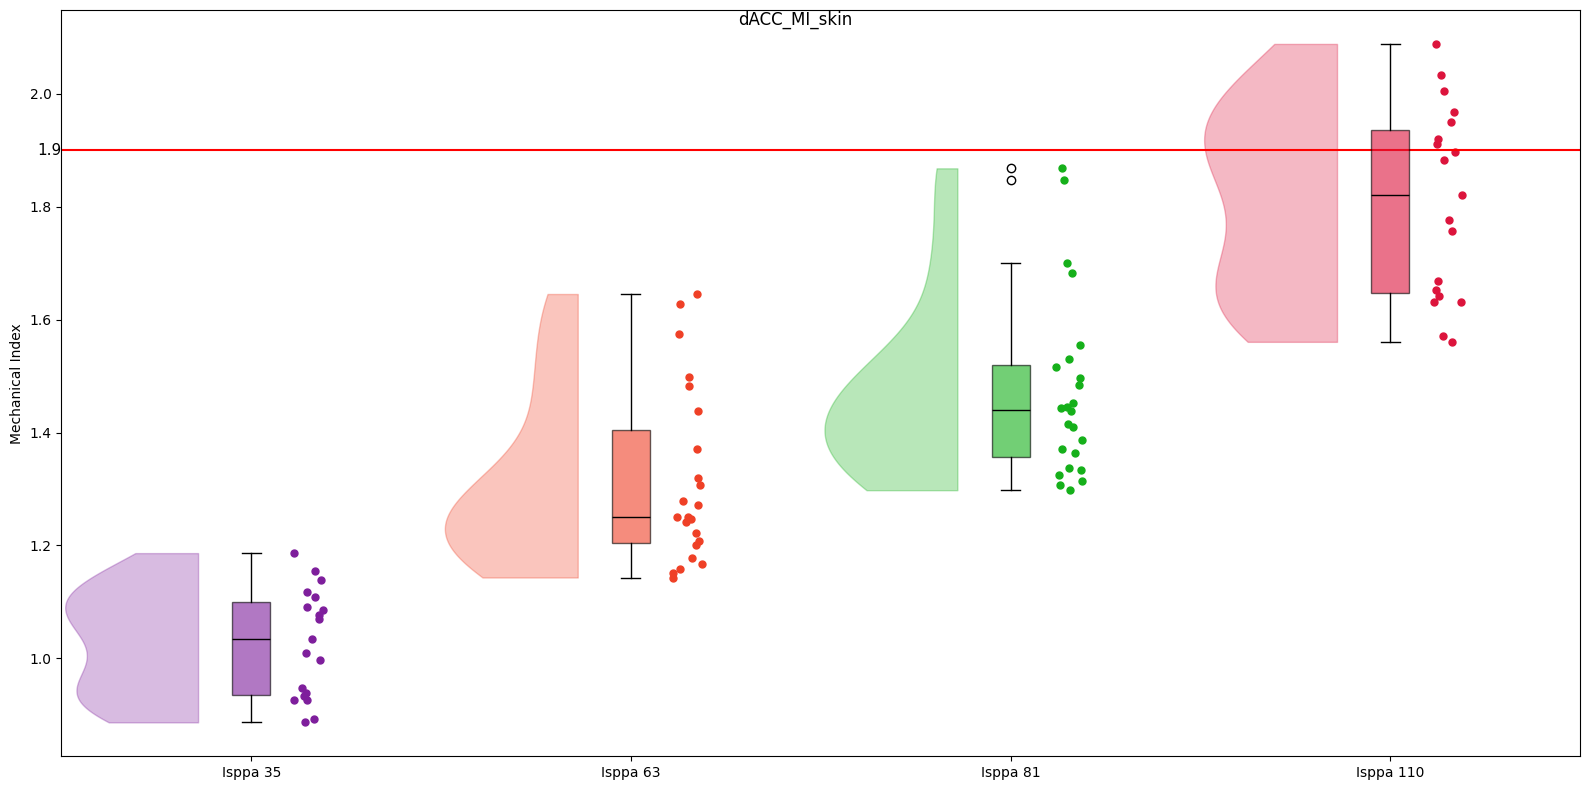

In [46]:
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6') | (stimulation_output['target'] == 'target_2_5') | (stimulation_output['target'] == 'target_2_4') | (stimulation_output['target'] == 'target_2_3') | (stimulation_output['target'] == 'target_2_2') | (stimulation_output['target'] == 'target_2_1')) & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '10%')]
list_1 = dataframe_filtered['max_MI_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6') | (stimulation_output['target'] == 'target_2_5') | (stimulation_output['target'] == 'target_2_4') | (stimulation_output['target'] == 'target_2_3') | (stimulation_output['target'] == 'target_2_2') | (stimulation_output['target'] == 'target_2_1')) & (stimulation_output['intensity'] == '63') & (stimulation_output['duty_cycle'] == '10%')]
list_2 = dataframe_filtered['max_MI_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6') | (stimulation_output['target'] == 'target_2_5') | (stimulation_output['target'] == 'target_2_4') | (stimulation_output['target'] == 'target_2_3') | (stimulation_output['target'] == 'target_2_2') | (stimulation_output['target'] == 'target_2_1')) & (stimulation_output['intensity'] == '81') & (stimulation_output['duty_cycle'] == '10%')]
list_3 = dataframe_filtered['max_MI_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6') | (stimulation_output['target'] == 'target_2_5') | (stimulation_output['target'] == 'target_2_4') | (stimulation_output['target'] == 'target_2_3') | (stimulation_output['target'] == 'target_2_2') | (stimulation_output['target'] == 'target_2_1')) & (stimulation_output['intensity'] == '110') & (stimulation_output['duty_cycle'] == '10%')]
list_4 = dataframe_filtered['max_MI_skin'].dropna().tolist()
raincloud_plot_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))
#ax.set_yscale('log')
plt.axhline(y = 1.9, color = 'r', linestyle = '-')
ax.text(x=0, y=1.9, s='1.9', va='center', ha='right',
        transform=ax.get_yaxis_transform(), fontsize=11)

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(raincloud_plot_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(raincloud_plot_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.7,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(raincloud_plot_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=25, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Isppa 35', 'Isppa 63', 'Isppa 81', 'Isppa 110'])
plt.ylabel('Mechanical Index')
plot_name = 'dACC_MI_skin'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(plot_dir, f'{plot_name}.pdf'))
plt.show()

#### Brain

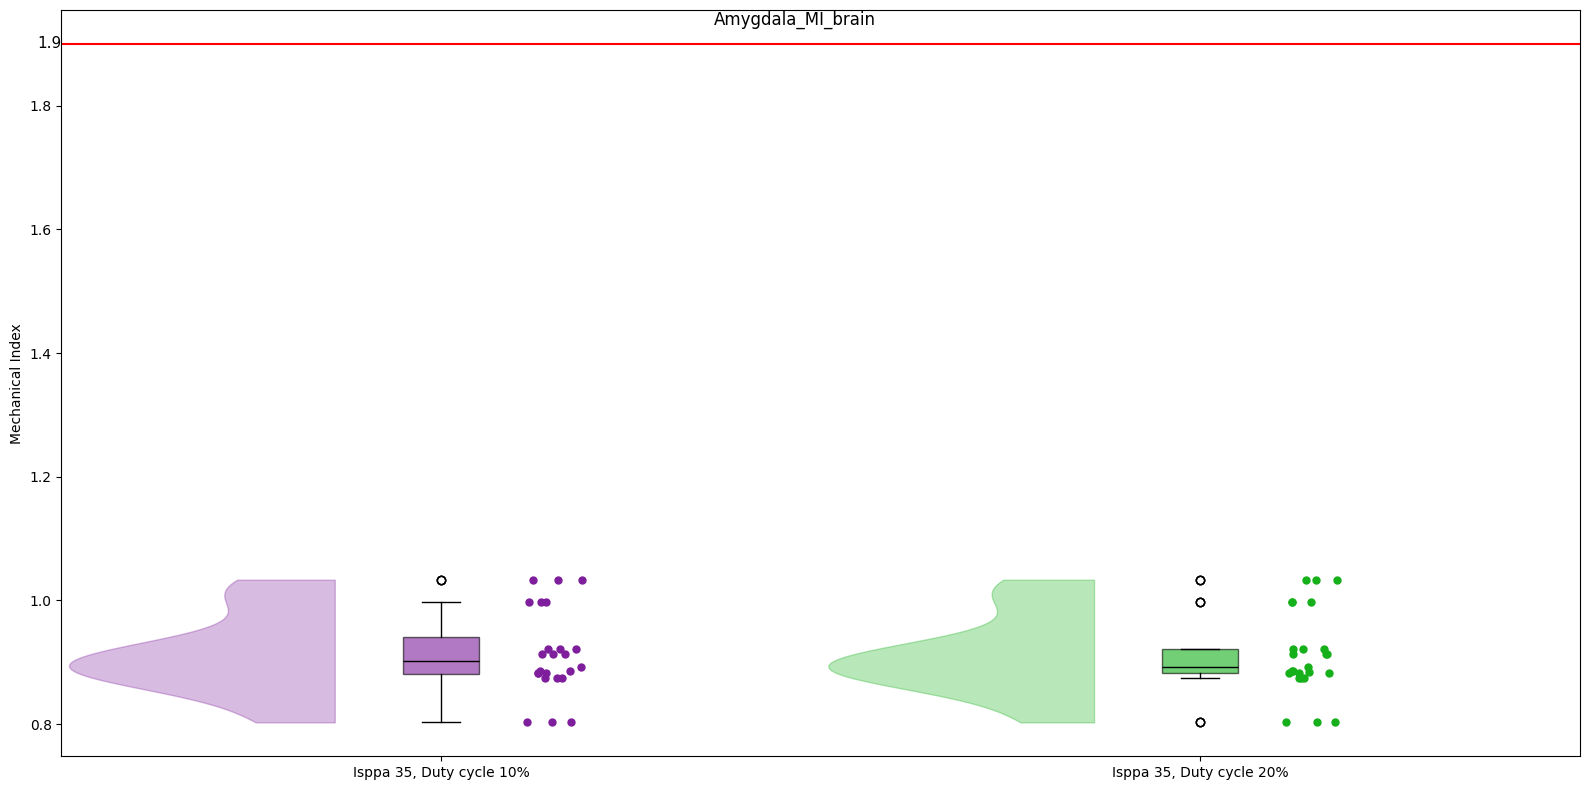

In [47]:
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_1_6') | (stimulation_output['target'] == 'target_1_5') | (stimulation_output['target'] == 'target_1_4') | (stimulation_output['target'] == 'target_1_3') | (stimulation_output['target'] == 'target_1_2') | (stimulation_output['target'] == 'target_1_1')) & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '10%')]
list_1 = dataframe_filtered['max_MI_brain'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_1_6') | (stimulation_output['target'] == 'target_1_5') | (stimulation_output['target'] == 'target_1_4') | (stimulation_output['target'] == 'target_1_3') | (stimulation_output['target'] == 'target_1_2') | (stimulation_output['target'] == 'target_1_1')) & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '20%')]
list_2 = dataframe_filtered['max_MI_brain'].dropna().tolist()
raincloud_plot_list = [list_1, list_2]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))
#ax.set_yscale('log')
plt.axhline(y = 1.9, color = 'r', linestyle = '-')
ax.text(x=0, y=1.9, s='1.9', va='center', ha='right',
        transform=ax.get_yaxis_transform(), fontsize=11)

# Create a list of colors
plot_colors = ['#7E1E9C', '#15B01A']
c = 'black'

# Boxplot data
bp = ax.boxplot(raincloud_plot_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(raincloud_plot_list, points=500, positions=[0.86, 1.86], widths=0.7,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(raincloud_plot_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=25, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Isppa 35, Duty cycle 10%', 'Isppa 35, Duty cycle 20%'])
plt.ylabel('Mechanical Index')
plot_name = 'Amygdala_MI_brain'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(plot_dir, f'{plot_name}.pdf'))
plt.show()

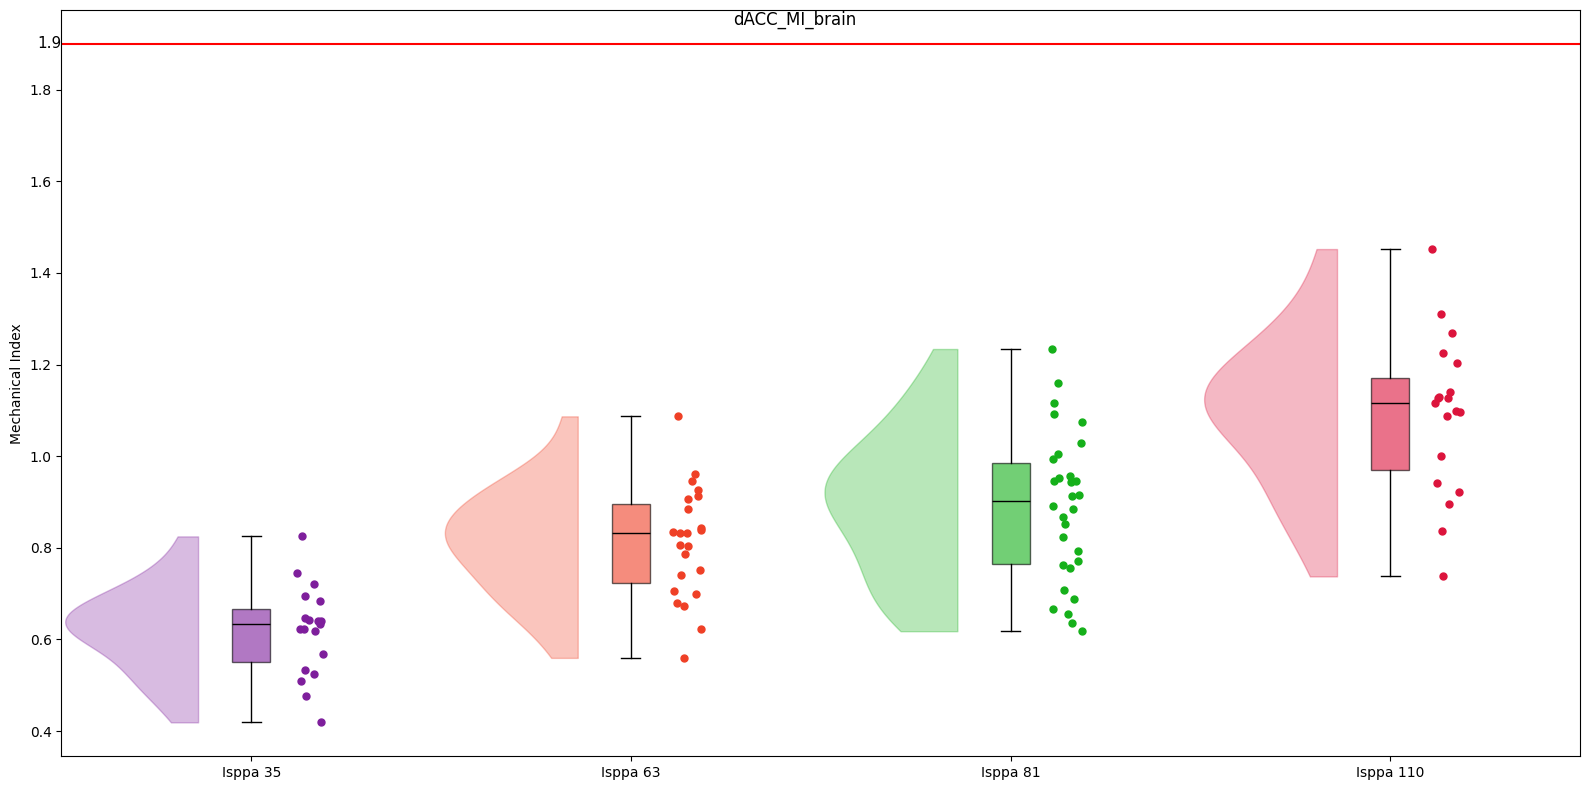

In [48]:
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6') | (stimulation_output['target'] == 'target_2_5') | (stimulation_output['target'] == 'target_2_4') | (stimulation_output['target'] == 'target_2_3') | (stimulation_output['target'] == 'target_2_2') | (stimulation_output['target'] == 'target_2_1')) & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '10%')]
list_1 = dataframe_filtered['max_MI_brain'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6') | (stimulation_output['target'] == 'target_2_5') | (stimulation_output['target'] == 'target_2_4') | (stimulation_output['target'] == 'target_2_3') | (stimulation_output['target'] == 'target_2_2') | (stimulation_output['target'] == 'target_2_1')) & (stimulation_output['intensity'] == '63') & (stimulation_output['duty_cycle'] == '10%')]
list_2 = dataframe_filtered['max_MI_brain'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6') | (stimulation_output['target'] == 'target_2_5') | (stimulation_output['target'] == 'target_2_4') | (stimulation_output['target'] == 'target_2_3') | (stimulation_output['target'] == 'target_2_2') | (stimulation_output['target'] == 'target_2_1')) & (stimulation_output['intensity'] == '81') & (stimulation_output['duty_cycle'] == '20%')]
list_3 = dataframe_filtered['max_MI_brain'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6') | (stimulation_output['target'] == 'target_2_5') | (stimulation_output['target'] == 'target_2_4') | (stimulation_output['target'] == 'target_2_3') | (stimulation_output['target'] == 'target_2_2') | (stimulation_output['target'] == 'target_2_1')) & (stimulation_output['intensity'] == '110') & (stimulation_output['duty_cycle'] == '20%')]
list_4 = dataframe_filtered['max_MI_brain'].dropna().tolist()
raincloud_plot_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))
#ax.set_yscale('log')
plt.axhline(y = 1.9, color = 'r', linestyle = '-')
ax.text(x=0, y=1.9, s='1.9', va='center', ha='right',
        transform=ax.get_yaxis_transform(), fontsize=11)

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(raincloud_plot_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(raincloud_plot_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.7,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(raincloud_plot_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=25, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Isppa 35', 'Isppa 63', 'Isppa 81', 'Isppa 110'])
plt.ylabel('Mechanical Index')
plot_name = 'dACC_MI_brain'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(plot_dir, f'{plot_name}.pdf'))
plt.show()

### CEM43
Aim for a value below 0.25, plot only maxCEM43.
Group by target, intensity and duty cycle

In [ ]:
dataframe_filtered = stimulation_output[(stimulation_output['target'] == 'target_1_6') & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '10%')]
list_1 = dataframe_filtered['maxCEM43'].dropna().tolist()
dataframe_filtered = stimulation_output[(stimulation_output['target'] == 'target_1_6') & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '20%')]
list_2 = dataframe_filtered['maxCEM43'].dropna().tolist()
print(dataframe_filtered[['subject_id', 'target', 'intensity', 'duty_cycle', 'maxCEM43']])
raincloud_plot_list = [list_1, list_2]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_yscale('log')
plt.axhline(y = 1.9, color = 'r', linestyle = '-')
ax.text(x=0, y=1.9, s='1.9', va='center', ha='right',
        transform=ax.get_yaxis_transform(), fontsize=11)

# Create a list of colors
plot_colors = ['#7E1E9C', '#15B01A']
c = 'black'

# Boxplot data
bp = ax.boxplot(raincloud_plot_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(raincloud_plot_list, points=500, positions=[0.86, 1.86], widths=0.7,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(raincloud_plot_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=25, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Isppa 35, Duty cycle 10%', 'Isppa 35, Duty cycle 20%'])
plt.ylabel('CEM43 (logarithmic scale)')
plot_name = 'Amygdala_CEM43'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(plot_dir, f'{plot_name}.pdf'))
plt.show()

     subject_id      target intensity duty_cycle  maxCEM43
11            3  target_1_6        35        20%  0.042115
90            5  target_1_6        35        20%  0.004857
152          10  target_1_6        35        20%  0.091719
221         702  target_1_6        35        20%  0.006151


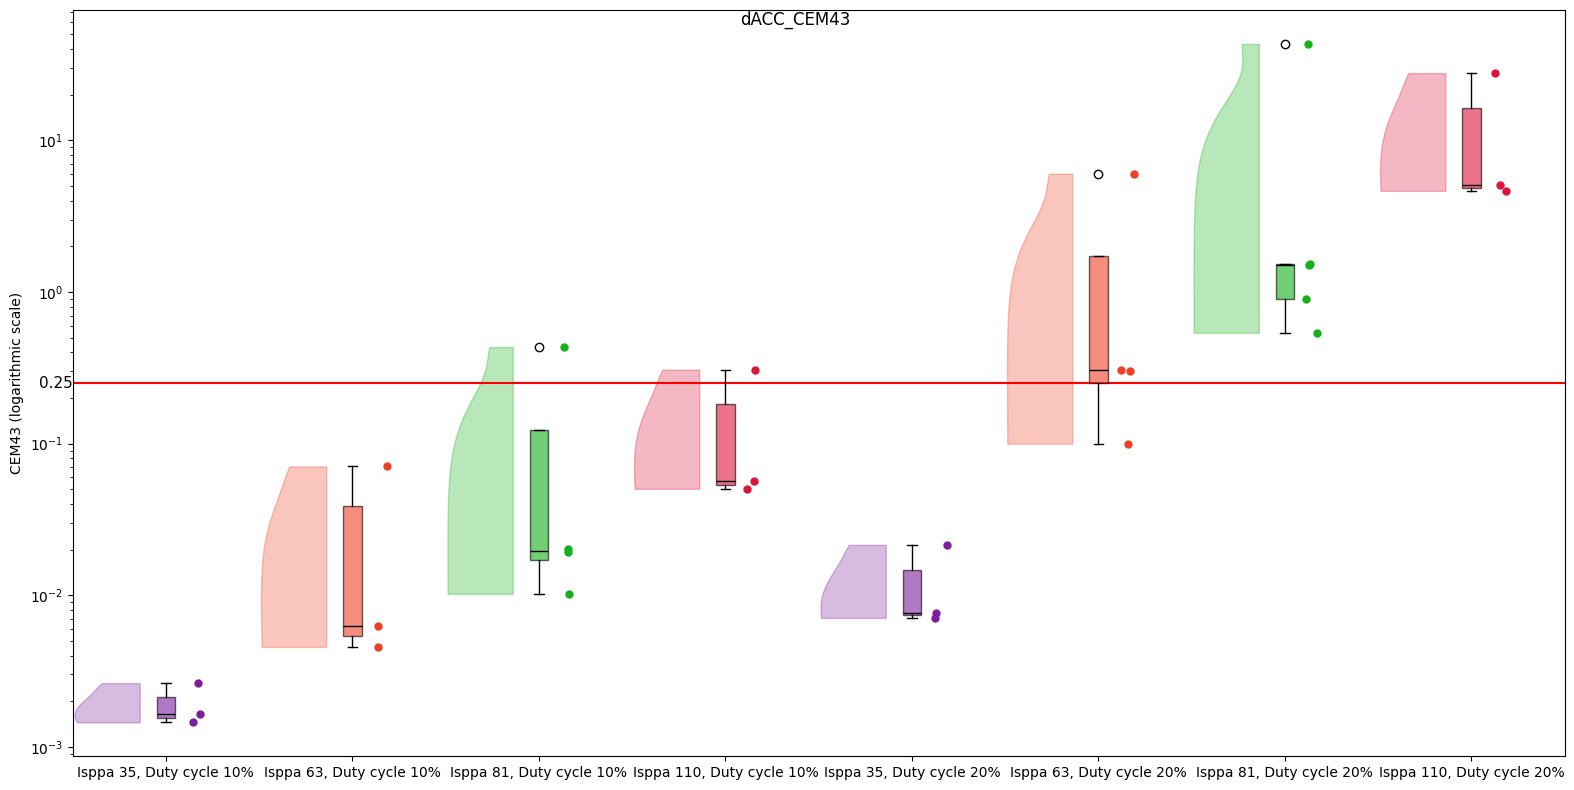

In [35]:
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '10%')]
list_1 = dataframe_filtered['maxCEM43'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '63') & (stimulation_output['duty_cycle'] == '10%')]
list_2 = dataframe_filtered['maxCEM43'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '81') & (stimulation_output['duty_cycle'] == '10%')]
list_3 = dataframe_filtered['maxCEM43'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '110') & (stimulation_output['duty_cycle'] == '10%')]
list_4 = dataframe_filtered['maxCEM43'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '20%')]
list_5 = dataframe_filtered['maxCEM43'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '63') & (stimulation_output['duty_cycle'] == '20%')]
list_6 = dataframe_filtered['maxCEM43'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '81') & (stimulation_output['duty_cycle'] == '20%')]
list_7 = dataframe_filtered['maxCEM43'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '110') & (stimulation_output['duty_cycle'] == '20%')]
list_8 = dataframe_filtered['maxCEM43'].dropna().tolist()
raincloud_plot_list = [list_1, list_2, list_3, list_4, list_5, list_6, list_7, list_8]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_yscale('log')
plt.axhline(y = 0.25, color = 'r', linestyle = '-')
ax.text(x=0, y=0.25, s='0.25', va='center', ha='right',
        transform=ax.get_yaxis_transform(), fontsize=11)

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C', '#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(raincloud_plot_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(raincloud_plot_list, points=500, positions=[0.86, 1.86, 2.86, 3.86, 4.86, 5.86, 6.86, 7.86], widths=0.7,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(raincloud_plot_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=25, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,9,1), ['Isppa 35, Duty cycle 10%', 'Isppa 63, Duty cycle 10%', 'Isppa 81, Duty cycle 10%', 'Isppa 110, Duty cycle 10%', 'Isppa 35, Duty cycle 20%', 'Isppa 63, Duty cycle 20%', 'Isppa 81, Duty cycle 20%', 'Isppa 110, Duty cycle 20%'])
plt.ylabel('CEM43 (logarithmic scale)')
plot_name = 'dACC_CEM43'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(plot_dir, f'{plot_name}.pdf'))
plt.show()

#### CEM43 in skin and brain

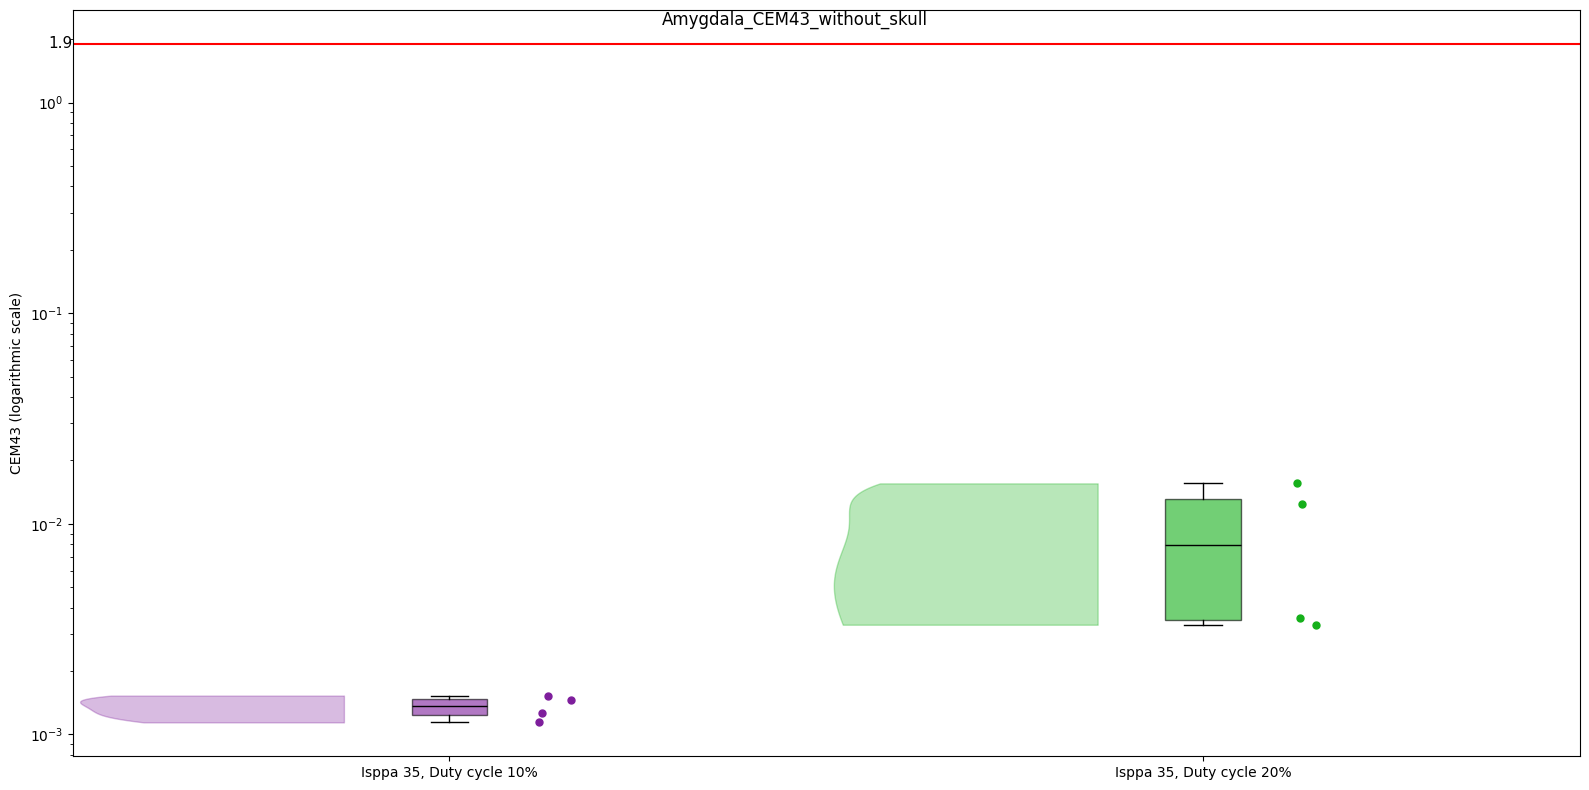

In [36]:
dataframe_filtered = stimulation_output[(stimulation_output['target'] == 'target_1_6') & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '10%')]
list_1 = dataframe_filtered['CEM43_brain_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[(stimulation_output['target'] == 'target_1_6') & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '20%')]
list_2 = dataframe_filtered['CEM43_brain_skin'].dropna().tolist()
raincloud_plot_list = [list_1, list_2]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_yscale('log')
plt.axhline(y = 1.9, color = 'r', linestyle = '-')
ax.text(x=0, y=1.9, s='1.9', va='center', ha='right',
        transform=ax.get_yaxis_transform(), fontsize=11)

# Create a list of colors
plot_colors = ['#7E1E9C', '#15B01A']
c = 'black'

# Boxplot data
bp = ax.boxplot(raincloud_plot_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(raincloud_plot_list, points=500, positions=[0.86, 1.86], widths=0.7,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(raincloud_plot_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=25, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Isppa 35, Duty cycle 10%', 'Isppa 35, Duty cycle 20%'])
plt.ylabel('CEM43 (logarithmic scale)')
plot_name = 'Amygdala_CEM43_without_skull'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(plot_dir, f'{plot_name}.pdf'))
plt.show()

     subject_id      target intensity duty_cycle  CEM43_brain_skin
68            3  target_2_6        81        20%          0.179378
79            4  target_2_6        81        20%          0.081273
139           5  target_2_6        81        20%          0.060540
208          10  target_2_6        81        20%          0.025598
263         702  target_2_6        81        20%          0.092347


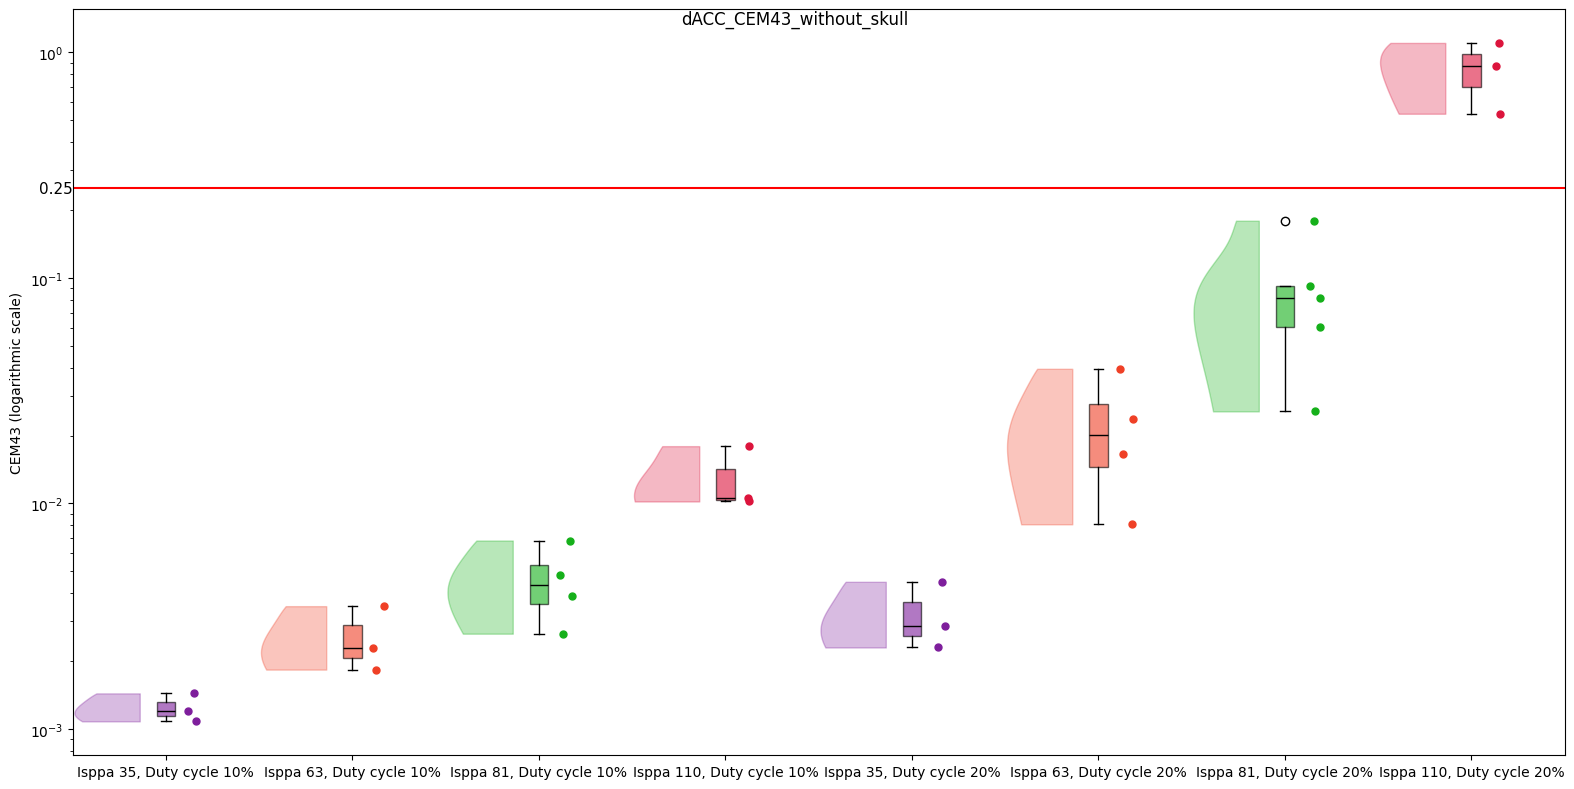

In [37]:
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '10%')]
list_1 = dataframe_filtered['CEM43_brain_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '63') & (stimulation_output['duty_cycle'] == '10%')]
list_2 = dataframe_filtered['CEM43_brain_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '81') & (stimulation_output['duty_cycle'] == '10%')]
list_3 = dataframe_filtered['CEM43_brain_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '110') & (stimulation_output['duty_cycle'] == '10%')]
list_4 = dataframe_filtered['CEM43_brain_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '35') & (stimulation_output['duty_cycle'] == '20%')]
list_5 = dataframe_filtered['CEM43_brain_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '63') & (stimulation_output['duty_cycle'] == '20%')]
list_6 = dataframe_filtered['CEM43_brain_skin'].dropna().tolist()
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '81') & (stimulation_output['duty_cycle'] == '20%')]
list_7 = dataframe_filtered['CEM43_brain_skin'].dropna().tolist()
print(dataframe_filtered[['subject_id', 'target', 'intensity', 'duty_cycle', 'CEM43_brain_skin']])
dataframe_filtered = stimulation_output[((stimulation_output['target'] == 'target_2_6')) & (stimulation_output['intensity'] == '110') & (stimulation_output['duty_cycle'] == '20%')]
list_8 = dataframe_filtered['CEM43_brain_skin'].dropna().tolist()
raincloud_plot_list = [list_1, list_2, list_3, list_4, list_5, list_6, list_7, list_8]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_yscale('log')
plt.axhline(y = 0.25, color = 'r', linestyle = '-')
ax.text(x=0, y=0.25, s='0.25', va='center', ha='right',
        transform=ax.get_yaxis_transform(), fontsize=11)

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C', '#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(raincloud_plot_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(raincloud_plot_list, points=500, positions=[0.86, 1.86, 2.86, 3.86, 4.86, 5.86, 6.86, 7.86], widths=0.7,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(raincloud_plot_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=25, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,9,1), ['Isppa 35, Duty cycle 10%', 'Isppa 63, Duty cycle 10%', 'Isppa 81, Duty cycle 10%', 'Isppa 110, Duty cycle 10%', 'Isppa 35, Duty cycle 20%', 'Isppa 63, Duty cycle 20%', 'Isppa 81, Duty cycle 20%', 'Isppa 110, Duty cycle 20%'])
plt.ylabel('CEM43 (logarithmic scale)')
plot_name = 'dACC_CEM43_without_skull'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(plot_dir, f'{plot_name}.pdf'))
plt.show()

### Average Ipa in brain and within ROI and fwhm overlap
Group by target, intensity and duty cycle